# Mobile Price Classification | Exploratory Data Analysis & Prediction

## Project Overview

This notebook explores a mobile phone dataset and builds classification models (Decision Tree, Random Forest and SVM) to predict the price range of a phone from its technical specifications. It covers data cleaning, exploratory analysis, a cross-validated check of which features to keep, and a fair comparison of the three models.

## Project Objective

**Business goal:** understand which technical specifications drive a phone's price segment, and predict the price range of a new phone (0 = low cost, 1 = medium cost, 2 = high cost, 3 = very high cost) from its specifications. This kind of analysis can support pricing and product-positioning decisions.

The target has four **ordered** classes, so besides accuracy I also report macro-F1 and confusion matrices, which show whether the mistakes fall between neighboring price ranges (less costly) or far apart (more costly).

## Dataset Overview

The training file contains the specifications of 2,000 mobile phones together with their price range. A second file with 1,000 phones has no price range, so it is only used at the end to generate predictions.

Source: Kaggle, Mobile Price Classification.

### Feature Description

| Feature | Description |
|---|---|
| battery_power | Total energy the battery can store (mAh) |
| blue | Has Bluetooth (1/0) |
| clock_speed | Speed at which the microprocessor executes instructions (GHz) |
| dual_sim | Has dual SIM support (1/0) |
| fc | Front camera (megapixels) |
| four_g | Has 4G (1/0) |
| int_memory | Internal memory (GB) |
| m_dep | Mobile depth (cm) |
| mobile_wt | Weight of the phone (g) |
| n_cores | Number of processor cores |
| pc | Primary camera (megapixels) |
| px_height | Pixel resolution height |
| px_width | Pixel resolution width |
| ram | Random access memory (MB) |
| sc_h | Screen height (cm) |
| sc_w | Screen width (cm) |
| talk_time | Longest time a single battery charge lasts during a call (hours) |
| three_g | Has 3G (1/0) |
| touch_screen | Has a touch screen (1/0) |
| wifi | Has Wi-Fi (1/0) |
| price_range | **Target:** 0 (low cost), 1 (medium cost), 2 (high cost), 3 (very high cost) |

## Tools & Libraries

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly
- Scikit-learn

## Import Libraries & Data

In [1]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Model selection & evaluation
from sklearn.base import clone
from sklearn.model_selection import (train_test_split, StratifiedKFold, GridSearchCV,
                                     cross_val_score, validation_curve)
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

# Preprocessing & models
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


def show(fig):
    """Show a Plotly figure as a static image (so it also renders on GitHub).
    Falls back to the interactive figure if static export is not available."""
    try:
        fig.show(renderer="png")
    except Exception:
        fig.show()

In [2]:
# Import data

Data = pd.read_csv("../data/train.csv")

# Work on a copy so the raw data stays untouched
df = Data.copy()

### Dataset Information

In [3]:
Data.head(10)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
5,1859,0,0.5,1,3,0,22,0.7,164,1,...,1004,1654,1067,17,1,10,1,0,0,1
6,1821,0,1.7,0,4,1,10,0.8,139,8,...,381,1018,3220,13,8,18,1,0,1,3
7,1954,0,0.5,1,0,0,24,0.8,187,4,...,512,1149,700,16,3,5,1,1,1,0
8,1445,1,0.5,0,0,0,53,0.7,174,7,...,386,836,1099,17,1,20,1,0,0,0
9,509,1,0.6,1,2,1,9,0.1,93,5,...,1137,1224,513,19,10,12,1,0,0,0


### Initial Dataset Inspection

The dataset was first inspected to understand its dimensions, structure, data types, and basic descriptive statistics.

In [4]:
Data.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [5]:
#Number_of_rows_columns

rows, columns = df.shape

print(f"The Number of rows in this Dataset is: {rows}")
print(f"The Number of columns in this Dataset is: {columns}")

The Number of rows in this Dataset is: 2000
The Number of columns in this Dataset is: 21


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

All columns are numeric: `clock_speed` and `m_dep` are decimals and the rest are integers. The binary features are already coded as 0/1, so no text-to-number conversion is needed.

In [7]:
#Column_Detail

def col_detail (df1):
    col_name = []
    dtypes = []
    count = []
    unique = []
    for col in df1.columns:
        col_name.append(col)
        dtypes.append(df1[col].dtype)
        count.append(len(df1[col]))
        unique.append(len(df1[col].unique()))

    output = pd.DataFrame({
        'Column_name' : col_name,
        'Dtype' : dtypes,
        'Count' : count,
        'Unique': unique
    })
    return output

col_detail(df)

,Column_name,Dtype,Count,Unique
0,battery_power,int64,2000,1094
1,blue,int64,2000,2
2,clock_speed,float64,2000,26
3,dual_sim,int64,2000,2
4,fc,int64,2000,20
5,four_g,int64,2000,2
6,int_memory,int64,2000,63
7,m_dep,float64,2000,10
8,mobile_wt,int64,2000,121
9,n_cores,int64,2000,8


## Data Cleaning

### Missing Values

In [8]:
Num_missing = df.isna().sum().sum()

if Num_missing == 0:
    print("There are no missing values in this dataset.")
else:
    print(f"There are {Num_missing} missing values in this dataset.")

There are no missing values in this dataset.


In this dataset we don’t have missing values, but we should also check for hidden characters and values used as placeholders for missing data such as `-` or `?`. All columns are numeric, so any text placeholder would have changed a column type to `object`; none did. Physically impossible values (such as zeros) are checked in the "Suspicious Values" section below.

### Duplicate Records

In [9]:
#Number_of_Duplicated_records

Num_dup = df.duplicated().sum()

if Num_dup == 0:
    print("There are no duplicated records in this dataset.")
else:
    print(f"There are {Num_dup} duplicated records in this dataset.")

There are no duplicated records in this dataset.


### Data Quality Checks

In [10]:
#Unique_Values

for column in df.columns:
    print(f"Unique Values in '{column}':")
    print(df[column].unique())
    print("_"*40)

Unique Values in 'battery_power':
[ 842 1021  563 ... 1139 1467  858]
________________________________________
Unique Values in 'blue':
[0 1]
________________________________________
Unique Values in 'clock_speed':
[2.2 0.5 2.5 1.2 1.7 0.6 2.9 2.8 2.1 1.  0.9 1.1 2.6 1.4 1.6 2.7 1.3 2.3
 2.  1.8 3.  1.5 1.9 2.4 0.8 0.7]
________________________________________
Unique Values in 'dual_sim':
[0 1]
________________________________________
Unique Values in 'fc':
[ 1  0  2 13  3  4  5  7 11 12 16  6 15  8  9 10 18 17 14 19]
________________________________________
Unique Values in 'four_g':
[0 1]
________________________________________
Unique Values in 'int_memory':
[ 7 53 41 10 44 22 24  9 33 17 52 46 13 23 49 19 39 47 38  8 57 51 21  5
 60 61  6 11 50 34 20 27 42 40 64 14 63 43 16 48 12 55 36 30 45 29 58 25
  3 54 15 37 31 32  4 18  2 56 26 35 59 28 62]
________________________________________
Unique Values in 'm_dep':
[0.6 0.7 0.9 0.8 0.1 0.5 1.  0.3 0.4 0.2]
____________________________

### Suspicious Values

In [11]:
# Zero values in columns where 0 is physically impossible

check_cols = ['battery_power', 'mobile_wt', 'ram', 'int_memory', 'px_width', 'px_height', 'sc_w', 'sc_h']
print("Number of zeros per column:")
print((df[check_cols] == 0).sum())

print("\nNumber of px_height values below 300:", (df['px_height'] < 300).sum())
print("Number of px_height values below 400:", (df['px_height'] < 400).sum())

Number of zeros per column:
battery_power      0
mobile_wt          0
ram                0
int_memory         0
px_width           0
px_height          2
sc_w             180
sc_h               0
dtype: int64

Number of px_height values below 300: 536
Number of px_height values below 400: 720


Two columns contain implausible values:

- `sc_w` has 180 zeros, i.e. a screen that is 0 cm wide.
- `px_height` has 2 zeros and many very small values (536 phones below 300 pixels and 720 below 400).

These values appear unusual for the intended feature definitions and may represent noisy or otherwise problematic observations. Removing the affected rows would mean losing between 27% and 36% of a 2,000 row dataset, so I keep all rows. Instead, I later test with cross validation whether these columns help the models or should be left out.

## Data Visualization

In [12]:
# Copy with price_range as text, so Plotly uses one color per class instead of a continuous color scale
plot_df = df.assign(price_range=df['price_range'].astype(str))
price_order = {'price_range': ['0', '1', '2', '3']}

### Target Distribution

price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64


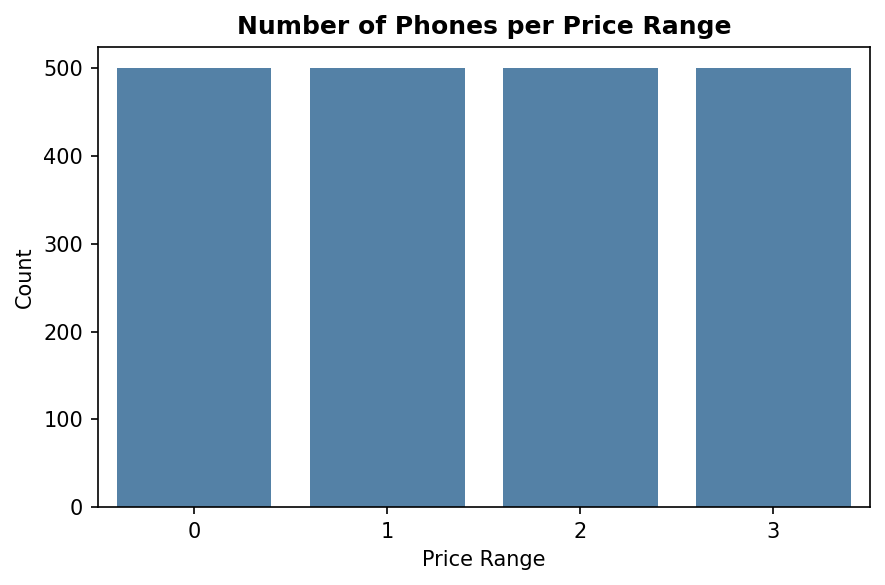

In [13]:
#Price_Range_Distribution

print(df['price_range'].value_counts().sort_index())

plt.figure(figsize=(6, 4), dpi=150)
sns.countplot(data=df, x='price_range', color='steelblue')
plt.title('Number of Phones per Price Range', fontsize=12, weight='bold')
plt.xlabel('Price Range')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The counts above show how balanced the four classes are. With balanced classes, accuracy is a fair headline metric; I still report macro-F1 and confusion matrices later.

### Binary Features

In [14]:
#value_count

binary_cols = ["blue", "dual_sim", "four_g", "three_g", "touch_screen", "wifi"]

for col in binary_cols:
    print(df[col].value_counts())
    print(10*"_")

blue
0    1010
1     990
Name: count, dtype: int64
__________
dual_sim
1    1019
0     981
Name: count, dtype: int64
__________
four_g
1    1043
0     957
Name: count, dtype: int64
__________
three_g
1    1523
0     477
Name: count, dtype: int64
__________
touch_screen
1    1006
0     994
Name: count, dtype: int64
__________
wifi
1    1014
0     986
Name: count, dtype: int64
__________


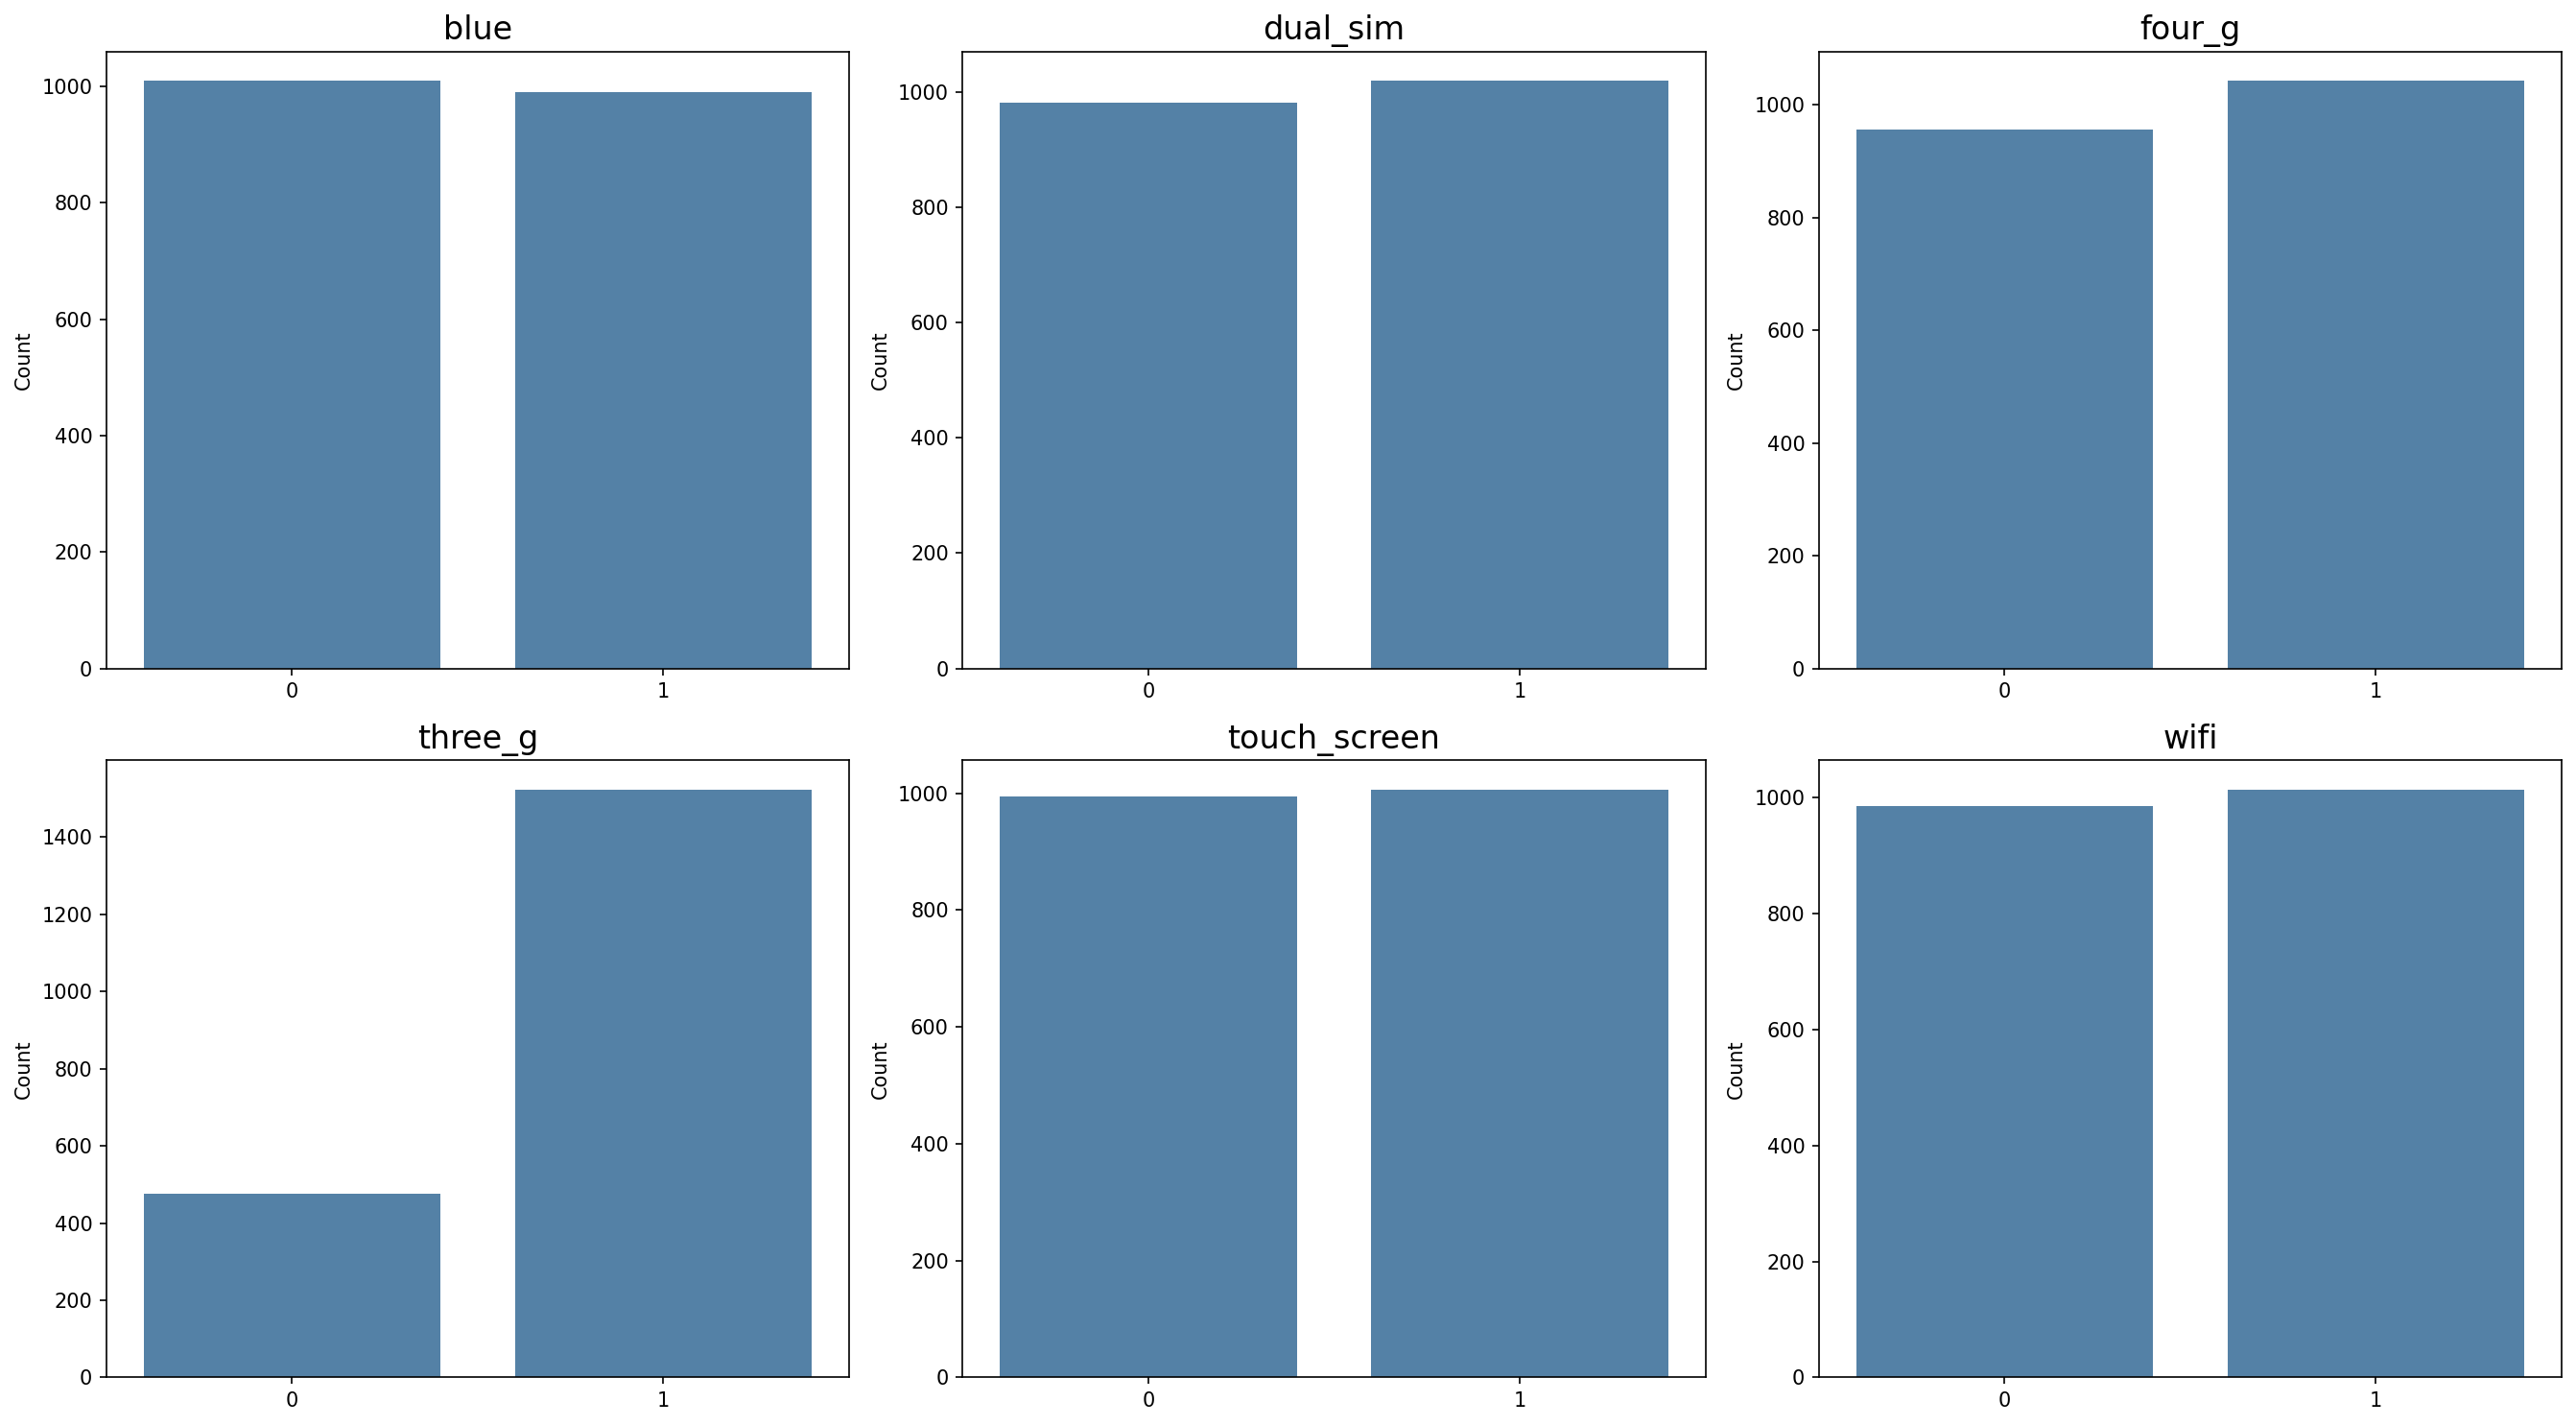

In [15]:
plt.figure(figsize=(18, 10), dpi=150)

for i, col in enumerate(binary_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=df, x=col, color='steelblue')
    plt.title(col, fontsize=16)
    plt.xlabel('')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

Most binary features are split almost evenly between "yes" and "no". The exception is `three_g`: about 76% of the phones support 3G.

In [16]:
# Share of phones that have each feature, per price range
df.groupby('price_range')[binary_cols].mean().round(3)

,blue,dual_sim,four_g,three_g,touch_screen,wifi
price_range,,,,,,
0,0.486,0.500,0.518,0.746,0.524,0.496
1,0.490,0.510,0.524,0.756,0.522,0.504
2,0.486,0.498,0.494,0.774,0.470,0.504
3,0.518,0.530,0.550,0.770,0.496,0.524


If the share of phones with a feature barely changes from one price range to the next, that feature carries little information about price. Compare the rows above with the correlation results later.

### Processor Power | clock_speed & n_cores

`clock_speed` is the speed of each processor core and `n_cores` is the number of cores. As a simple proxy for overall processing capacity, I create a new column `proc_power = clock_speed × n_cores`. It is only a rough heuristic (real performance also depends on the chip architecture), so the correlations below compare it with the two original columns. The original columns are kept for now.

In [17]:
#Create_new_column

df["proc_power"] = df["clock_speed"] * df["n_cores"]

print("Minimum proc_power:", df["proc_power"].min())
print("Maximum proc_power:", df["proc_power"].max())

# Correlation with the target
df[["clock_speed", "n_cores", "proc_power", "price_range"]].corr()["price_range"].drop("price_range").round(3)

Minimum proc_power: 0.5
Maximum proc_power: 24.0


clock_speed   -0.007
n_cores        0.004
proc_power    -0.008
Name: price_range, dtype: float64

### Screen Size & Depth | sc_w, sc_h, m_dep

In [18]:
for col in ['m_dep', 'sc_w', 'sc_h']:
    print(df[col].value_counts().sort_index())
    print(10*"_")

m_dep
0.1    320
0.2    213
0.3    199
0.4    168
0.5    205
0.6    186
0.7    200
0.8    208
0.9    195
1.0    106
Name: count, dtype: int64
__________
sc_w
0     180
1     210
2     156
3     199
4     182
5     161
6     130
7     132
8     125
9      97
10    107
11     84
12     68
13     49
14     33
15     31
16     29
17     19
18      8
Name: count, dtype: int64
__________
sc_h
5      97
6     114
7     151
8     117
9     124
10    125
11    126
12    157
13    131
14    143
15    135
16    143
17    193
18    120
19    124
Name: count, dtype: int64
__________


In [19]:
# A rough "size" proxy: screen width x screen height x depth (used for this check only, not added to the data)
size = df['sc_w'] * df['sc_h'] * df['m_dep'] * 10

for name, series in {'size (sc_w x sc_h x m_dep)': size, 'm_dep': df['m_dep'],
                     'sc_w': df['sc_w'], 'sc_h': df['sc_h']}.items():
    print(f"Correlation of {name} with price_range: {series.corr(df['price_range']):.3f}")

Correlation of size (sc_w x sc_h x m_dep) with price_range: 0.027
Correlation of m_dep with price_range: 0.001
Correlation of sc_w with price_range: 0.039
Correlation of sc_h with price_range: 0.023


**Result:** 180 phones have `sc_w = 0`, which also makes the combined size zero, and all four measurements have a very low correlation with the price range (below 0.04 in absolute value). These columns carry almost no linear information about price and contain implausible values, so they are candidates for removal; the feature check in the modeling section tests this instead of assuming it.

### Battery Power

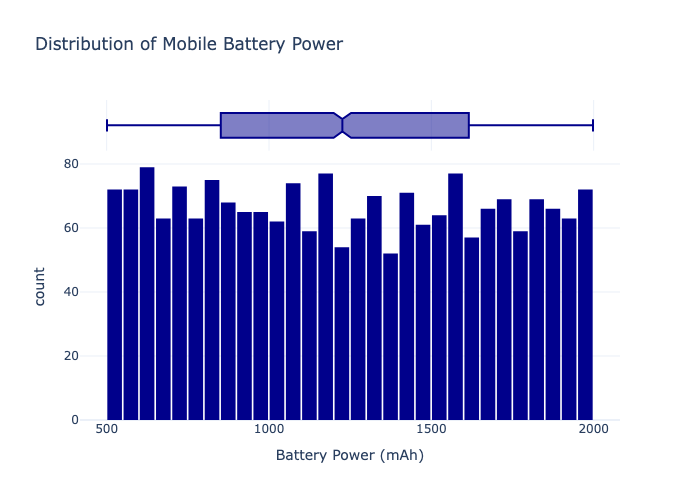

In [20]:
fig = px.histogram(plot_df, x="battery_power", nbins=30,
    title="Distribution of Mobile Battery Power",
    labels={"battery_power": "Battery Power (mAh)"},
    color_discrete_sequence=["darkblue"],
    marginal="box")

fig.update_layout(bargap=0.1, template="plotly_white")
show(fig)

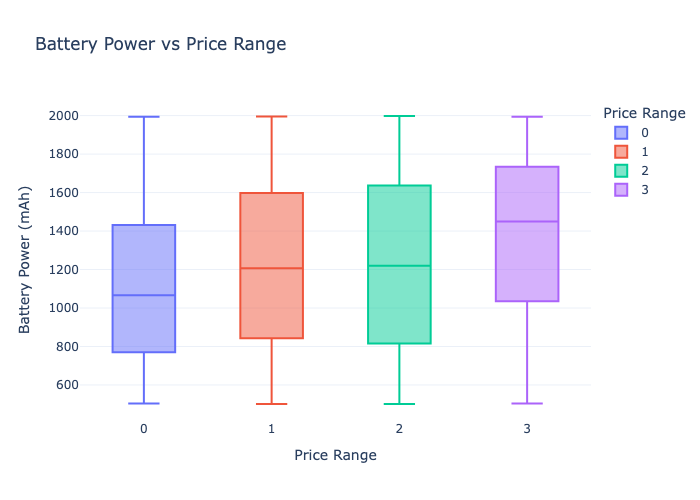

In [21]:
fig = px.box(plot_df, x="price_range", y="battery_power", color="price_range",
    category_orders=price_order,
    title="Battery Power vs Price Range",
    labels={"battery_power": "Battery Power (mAh)", "price_range": "Price Range"})

fig.update_layout(template="plotly_white")
show(fig)

### Front Camera

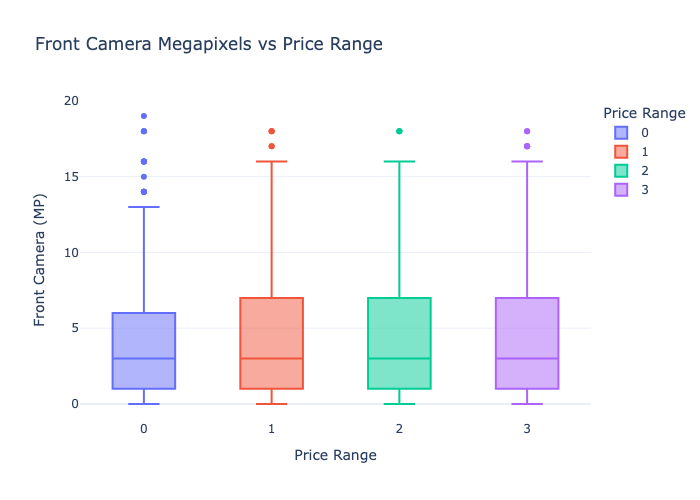

In [22]:
fig = px.box(plot_df, x="price_range", y="fc", color="price_range",
    category_orders=price_order,
    title="Front Camera Megapixels vs Price Range",
    labels={"fc": "Front Camera (MP)", "price_range": "Price Range"})

fig.update_layout(template="plotly_white")
show(fig)

### Internal Memory

In [23]:
print("Minimum internal memory:", df["int_memory"].min())
print("Maximum internal memory:", df["int_memory"].max())

Minimum internal memory: 2
Maximum internal memory: 64


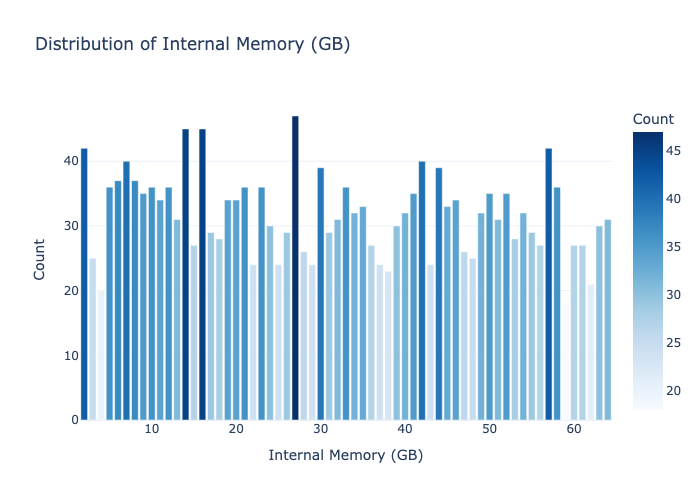

In [24]:
#Distribution_of_Internal_Memory

intm_counts = df["int_memory"].value_counts().sort_index().reset_index()
intm_counts.columns = ["int_memory", "count"]

fig = px.bar(intm_counts, x="int_memory", y="count",
    title="Distribution of Internal Memory (GB)",
    labels={"int_memory": "Internal Memory (GB)", "count": "Count"},
    color="count", color_continuous_scale="Blues")

fig.update_layout(template="plotly_white")
show(fig)

**Result:** given the dataset’s collection period, 2 GB and 3 GB of internal memory remain plausible for older smartphone models.

### Mobile Weight

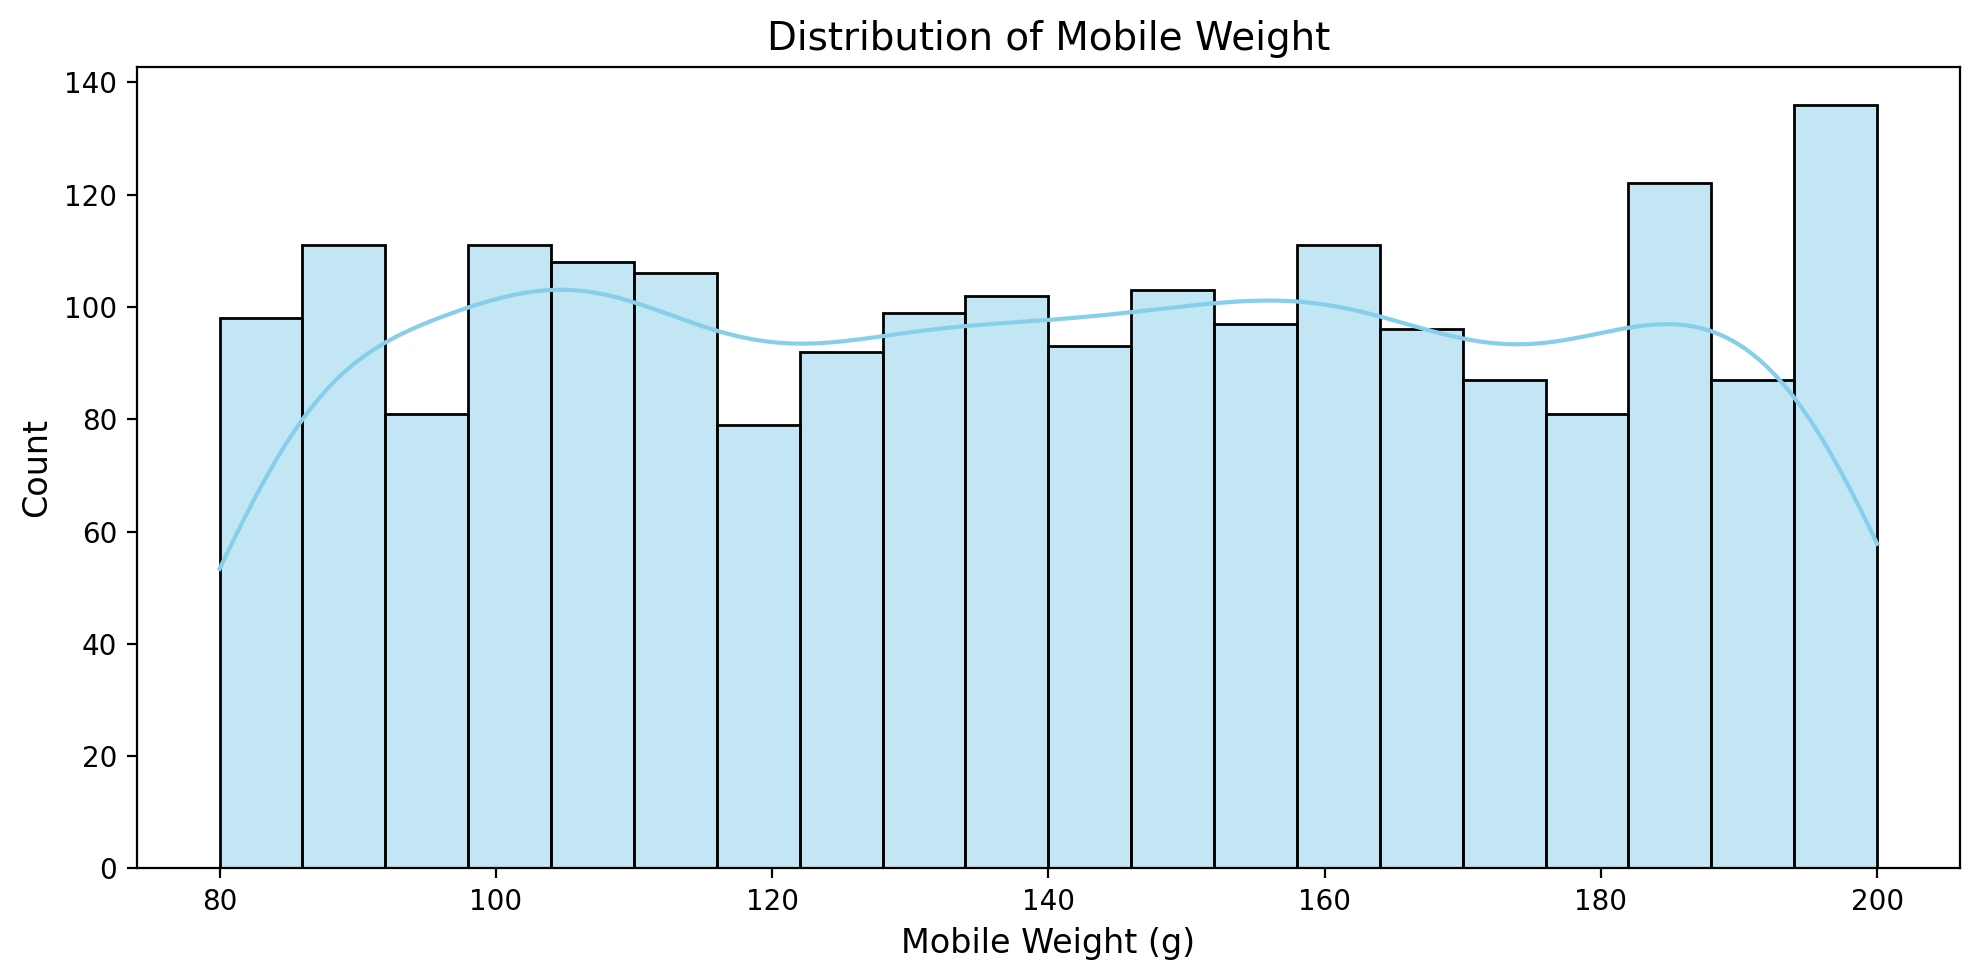

In [25]:
#Distribution_of_Mobile_Weight

plt.figure(figsize=(10, 5), dpi=200)
sns.histplot(df["mobile_wt"], bins=20, kde=True, color="skyblue")

plt.title("Distribution of Mobile Weight", fontsize=14)
plt.xlabel("Mobile Weight (g)", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.tight_layout()
plt.show()

### RAM

In [26]:
print("Minimum RAM:", df["ram"].min())
print("Maximum RAM:", df["ram"].max())

Minimum RAM: 256
Maximum RAM: 3998


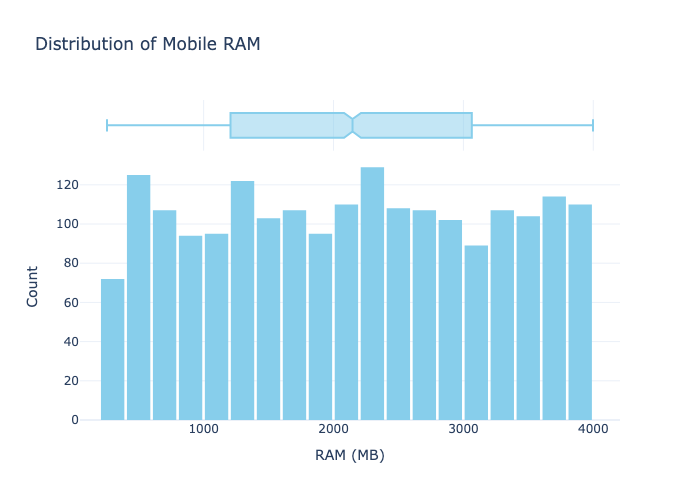

In [27]:
fig = px.histogram(plot_df, x="ram", nbins=30,
    title="Distribution of Mobile RAM",
    labels={"ram": "RAM (MB)"},
    color_discrete_sequence=["skyblue"],
    marginal="box")

fig.update_layout(bargap=0.1, xaxis_title="RAM (MB)", yaxis_title="Count", template="plotly_white")
show(fig)

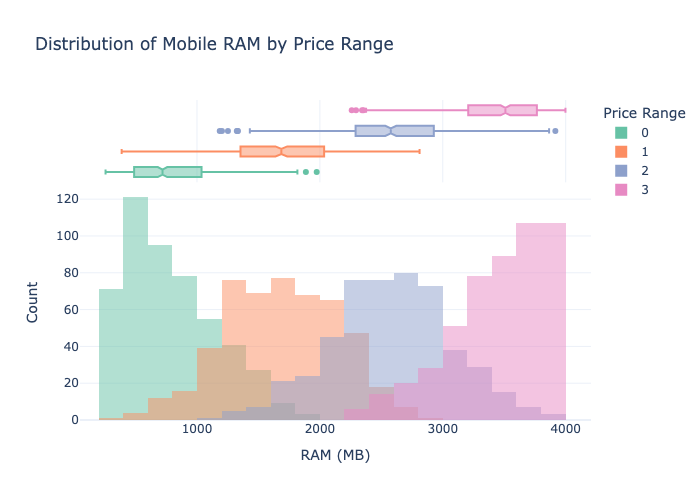

In [28]:
#Distribution_of_Mobile_ram_by_Price_Range

fig = px.histogram(plot_df, x="ram", color="price_range", nbins=30,
    marginal="box", barmode="overlay",
    category_orders=price_order,
    title="Distribution of Mobile RAM by Price Range",
    labels={"ram": "RAM (MB)", "price_range": "Price Range"},
    color_discrete_sequence=px.colors.qualitative.Set2)

fig.update_layout(xaxis_title="RAM (MB)", yaxis_title="Count", template="plotly_white")
show(fig)

**Result:** in the plot above, phones with more RAM generally belong to higher price ranges. The classes are clearly separated by RAM, which suggests a strong positive relationship between RAM and price.

### Talk Time

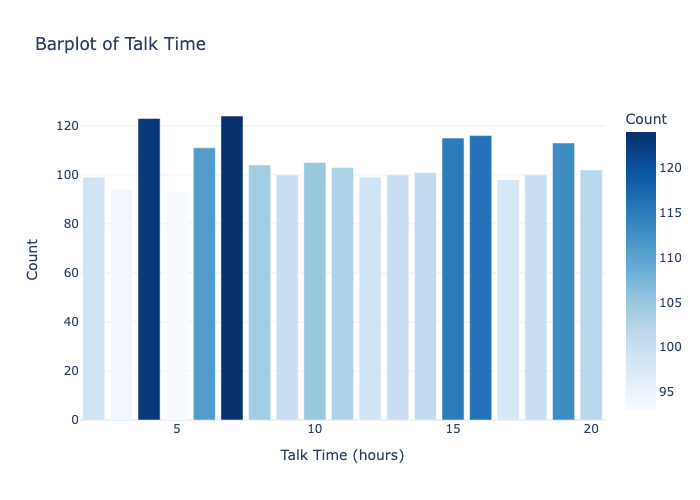

In [29]:
talk_time_counts = df["talk_time"].value_counts().sort_index().reset_index()
talk_time_counts.columns = ["talk_time", "count"]

fig = px.bar(talk_time_counts, x="talk_time", y="count",
    title="Barplot of Talk Time",
    labels={"talk_time": "Talk Time (hours)", "count": "Count"},
    color="count", color_continuous_scale="Blues")

fig.update_layout(template="plotly_white")
show(fig)

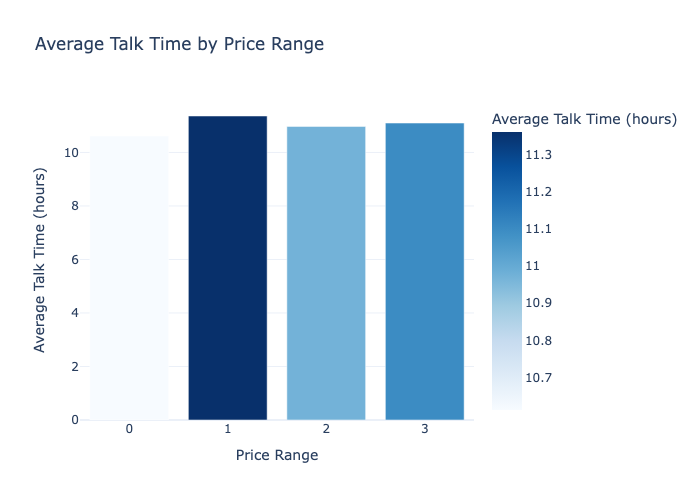

In [30]:
avg_talk_time = df.groupby("price_range")["talk_time"].mean().reset_index()

fig = px.bar(avg_talk_time, x="price_range", y="talk_time",
    color="talk_time", color_continuous_scale="Blues",
    title="Average Talk Time by Price Range",
    labels={"price_range": "Price Range", "talk_time": "Average Talk Time (hours)"})

fig.update_layout(template="plotly_white")
show(fig)

### Primary Camera

In [31]:
print("Minimum primary camera:", df["pc"].min())
print("Maximum primary camera:", df["pc"].max())

Minimum primary camera: 0
Maximum primary camera: 20


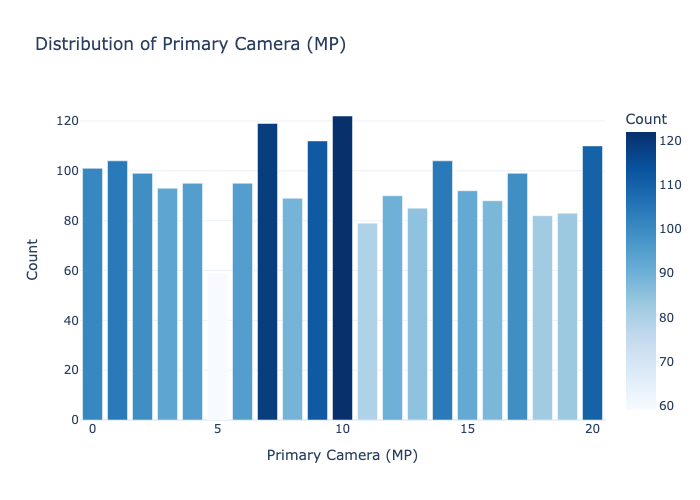

In [32]:
pc_counts = df["pc"].value_counts().sort_index().reset_index()
pc_counts.columns = ["pc", "count"]

fig = px.bar(pc_counts, x="pc", y="count",
    title="Distribution of Primary Camera (MP)",
    labels={"pc": "Primary Camera (MP)", "count": "Count"},
    color="count", color_continuous_scale="Blues")

fig.update_layout(template="plotly_white")
show(fig)

### Pixel Resolution | px_height & px_width

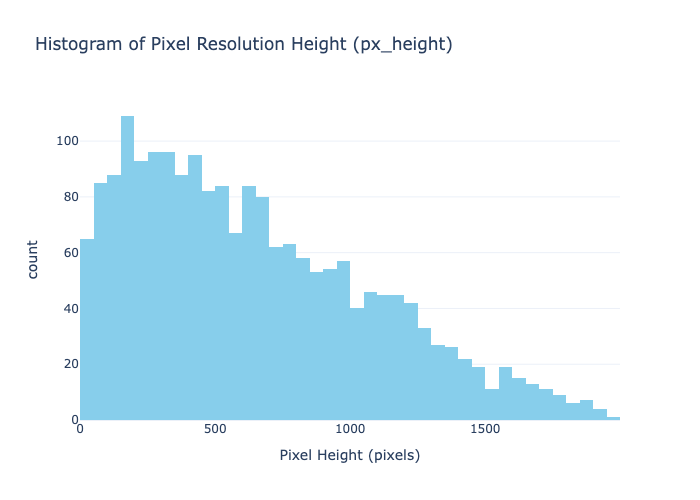

In [33]:
fig = px.histogram(plot_df, x="px_height", nbins=50,
    title="Histogram of Pixel Resolution Height (px_height)",
    labels={"px_height": "Pixel Height (pixels)"},
    color_discrete_sequence=["skyblue"])

fig.update_layout(template="plotly_white")
show(fig)

In [34]:
print("Number of unique values in px_height:", df["px_height"].nunique())
print("Correlation of px_height with price_range:", round(df["px_height"].corr(df["price_range"]), 3))

Number of unique values in px_height: 1137
Correlation of px_height with price_range: 0.149


`px_height` has many very small values (see "Suspicious Values") and a weak linear correlation with the price range (0.149). Low linear correlation alone is not a good reason to drop a feature, because a feature can still help through non-linear effects or in combination with other features. I therefore leave this decision to the cross-validated feature check below.

In [35]:
print("Minimum px_width:", df["px_width"].min())
print("Maximum px_width:", df["px_width"].max())

Minimum px_width: 500
Maximum px_width: 1998


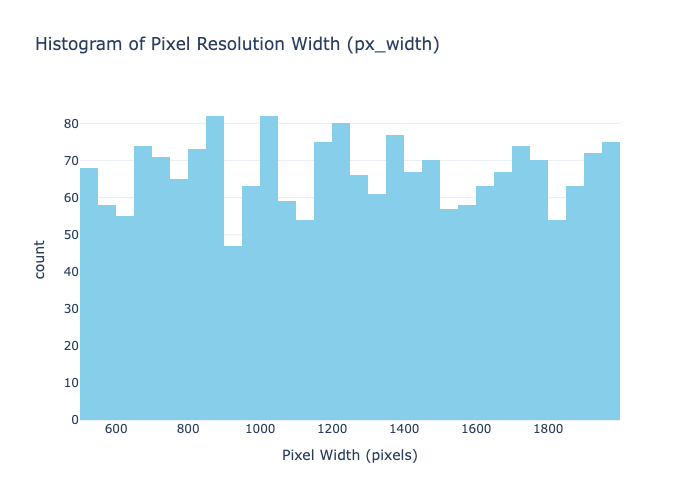

In [36]:
#histogram
#px_width

fig = px.histogram(plot_df, x="px_width", nbins=50,
    title="Histogram of Pixel Resolution Width (px_width)",
    labels={"px_width": "Pixel Width (pixels)"},
    color_discrete_sequence=["skyblue"])

fig.update_layout(template="plotly_white")
show(fig)

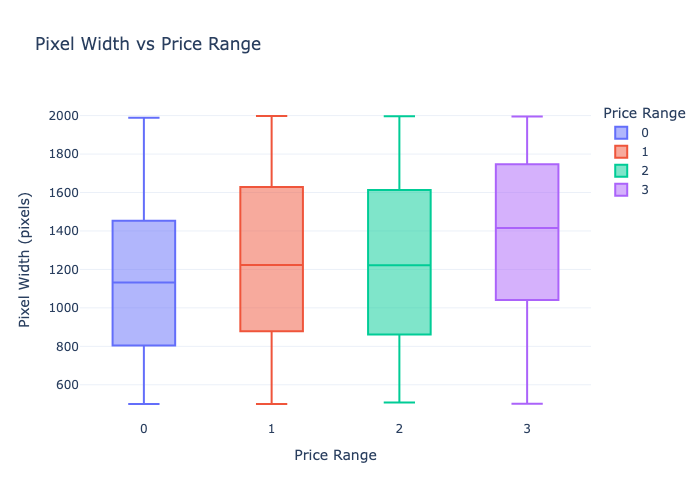

In [37]:
fig = px.box(plot_df, x="price_range", y="px_width", color="price_range",
    category_orders=price_order,
    title="Pixel Width vs Price Range",
    labels={"px_width": "Pixel Width (pixels)", "price_range": "Price Range"})

fig.update_layout(template="plotly_white")
show(fig)

## Correlation

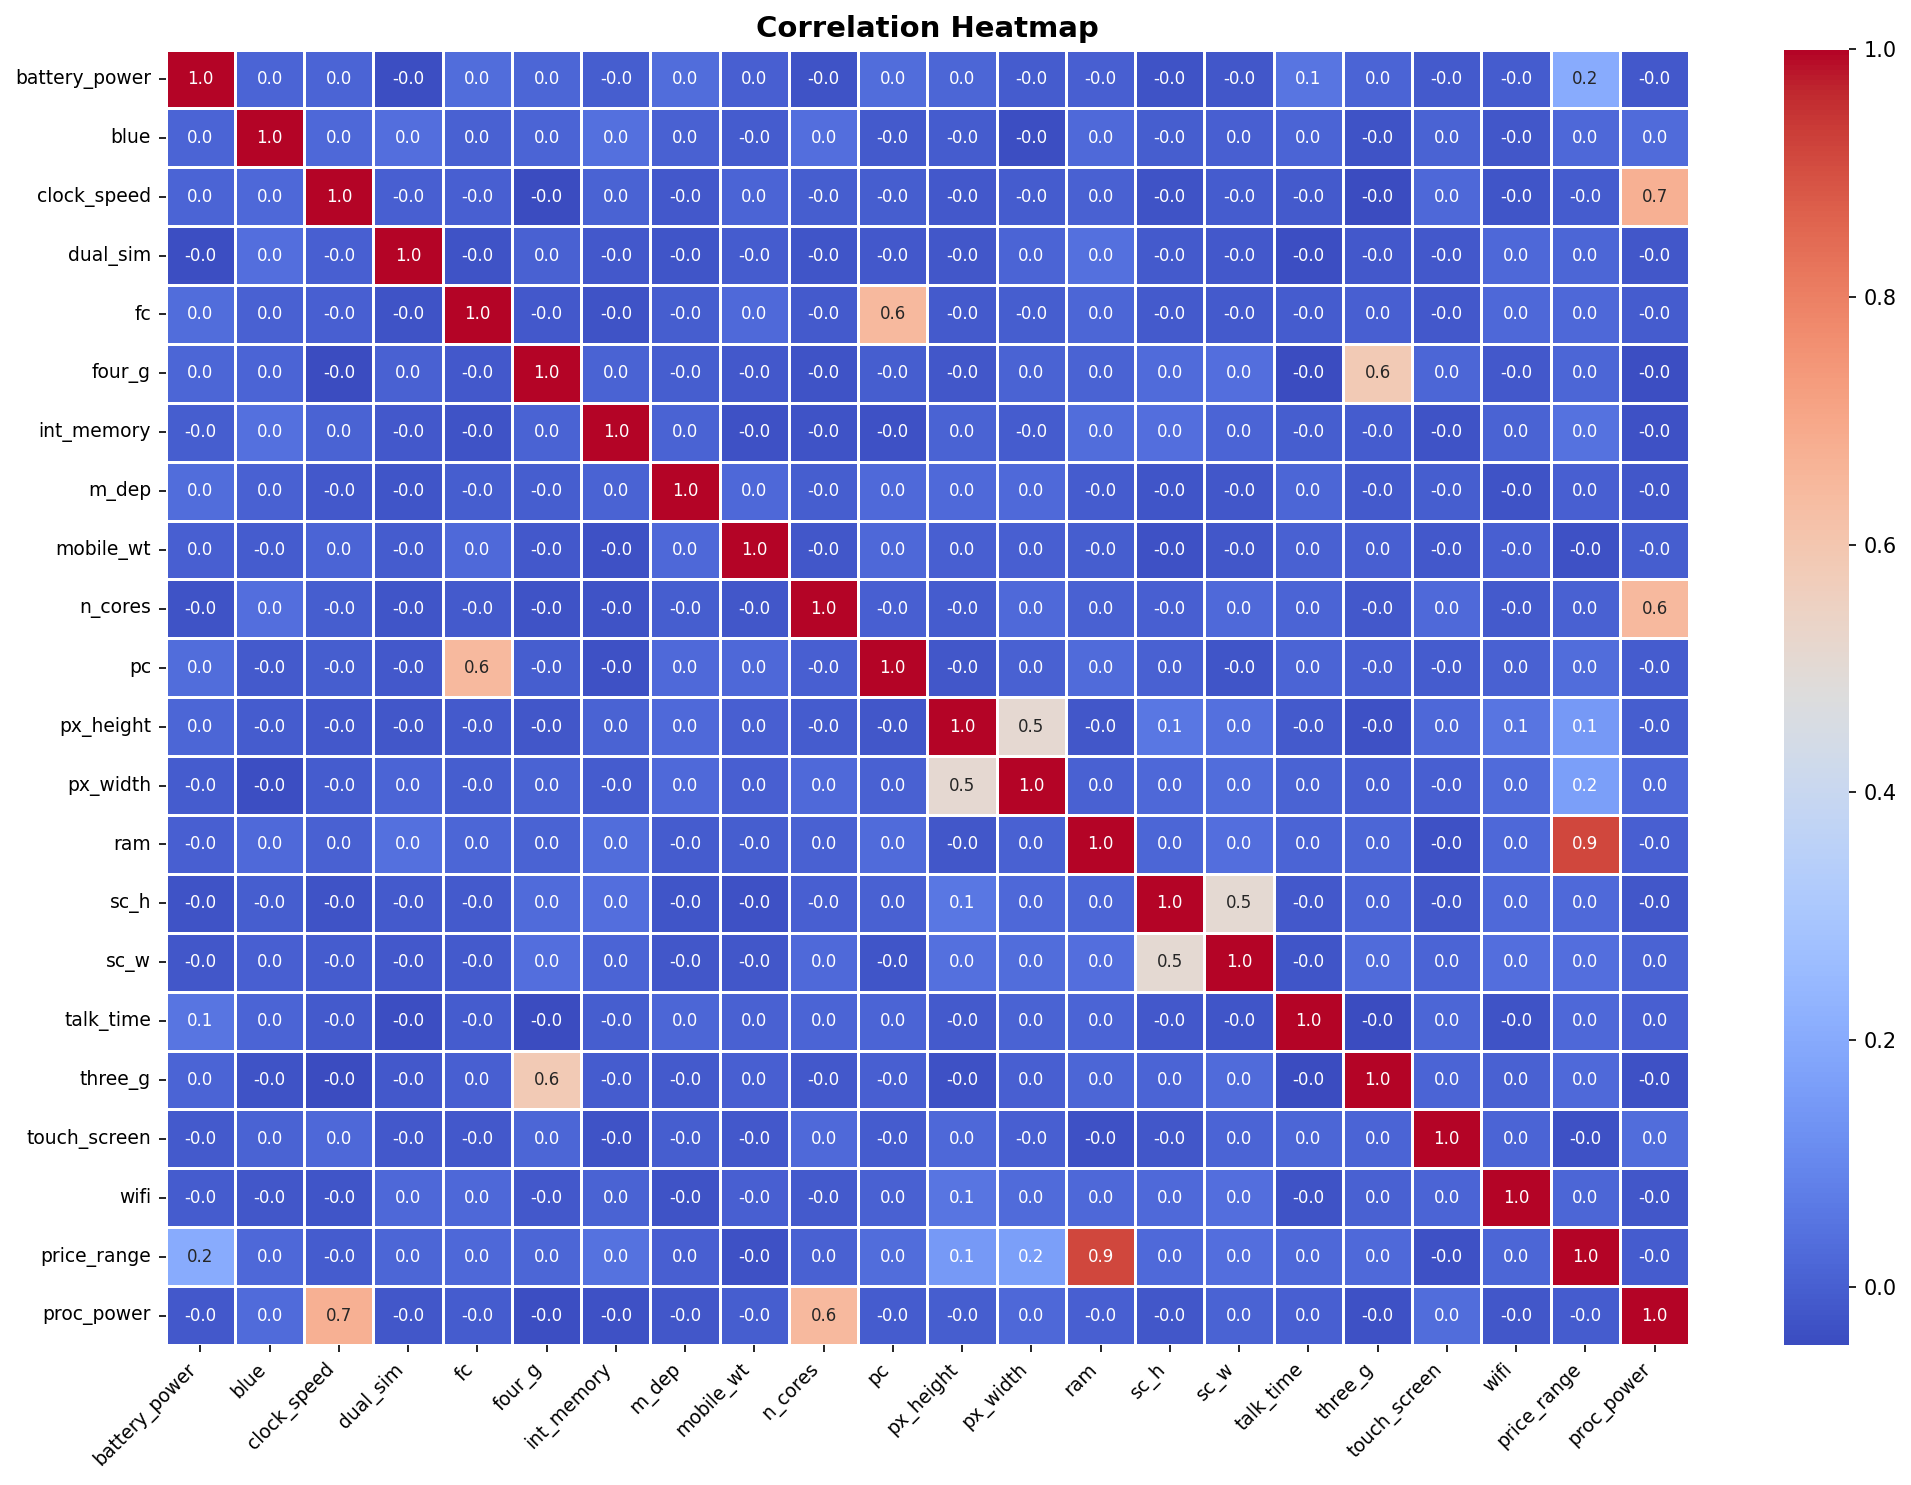

In [38]:
cor_matrix = df.corr()

plt.figure(figsize=(14, 10), dpi=150)
sns.heatmap(cor_matrix, annot=True, fmt=".1f", cmap="coolwarm",
            linewidths=.5, annot_kws={"size": 8})

plt.xticks(fontsize=9, rotation=45, ha="right")
plt.yticks(fontsize=9, rotation=0)
plt.title("Correlation Heatmap", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

### Features Most Correlated with the Target

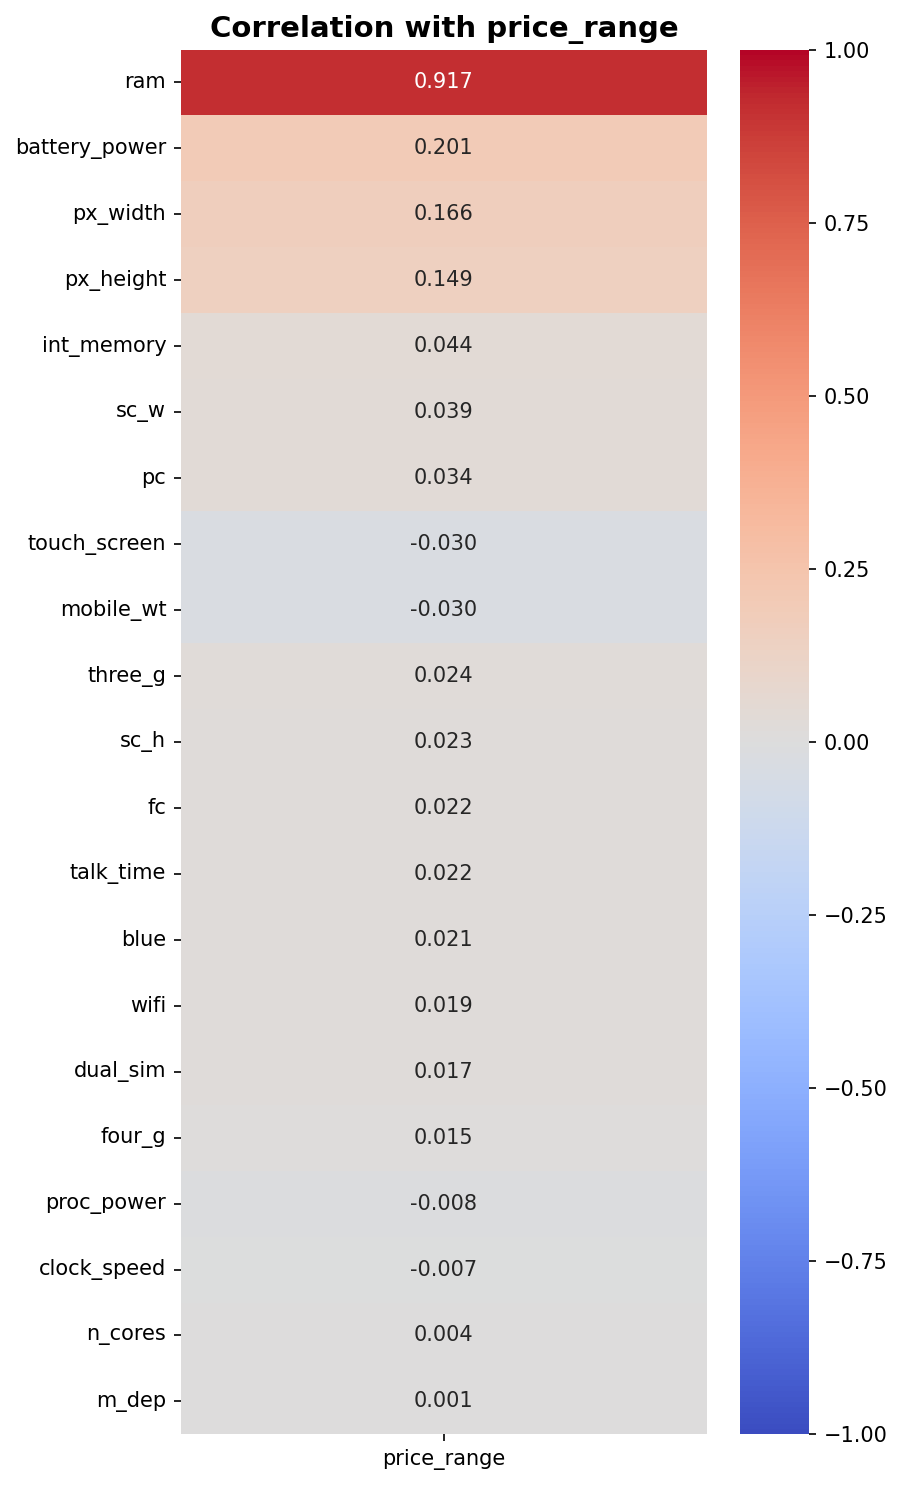

In [39]:
#Correlation_with_target
#Sort_by_absolute_value

price_range_corr = df.corr()["price_range"].drop("price_range")
corr_sorted = price_range_corr.abs().sort_values(ascending=False)
corr_df = price_range_corr.loc[corr_sorted.index].to_frame(name="price_range")

#HeatMap
plt.figure(figsize=(6, 10), dpi=150)
sns.heatmap(corr_df, annot=True, fmt=".3f", cmap="coolwarm", cbar=True, vmin=-1, vmax=1)

plt.title("Correlation with price_range", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

**Result:** `ram` has by far the strongest relationship with the price range, followed by `battery_power` and the pixel resolution columns (`px_width`, `px_height`). Higher-priced phones have clearly more RAM and better battery power and resolution. Mobile weight and talk time show almost no relationship with the price range.

Correlation only captures linear relationships with the target and is not the same as feature importance. The feature importances of the Random Forest later give a second view.

## Modeling Setup

- **Target:** `price_range`; **features:** all the other columns.
- **Split:** one stratified 80/20 train/test split. The split ratio is not a hyperparameter, so I do not compare different ratios on the test set, and every model is evaluated on the same test set.
- **Model selection:** hyperparameters (and the feature set) are chosen with 5-fold stratified cross-validation on the **training set only**; the test set is used once at the end.
- **Scaling:** the SVM needs scaled features, so the scaler is placed inside a `Pipeline` and fitted on training data only (this avoids data leakage). Tree-based models do not need scaling.

In [40]:
# Features and target
X = df.drop(columns=['price_range'])
y = df['price_range']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

# Stratified 5-fold cross-validation, reused everywhere
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_train: (1600, 21) | X_test: (400, 21)


### Feature Check | Which Columns Should the Models Use?

The EDA raised doubts about six columns: `clock_speed` and `n_cores` (combined into `proc_power`), `m_dep`, `sc_w`, `sc_h` (very low correlation and implausible values) and `px_height`. Instead of deciding by intuition, I compare three feature sets with cross-validation on the training set, using three quick models (Random Forest, RBF SVM and linear SVM), and continue with the set that has the best average score.

- **Reduced (EDA choice):** the six doubtful columns removed, `proc_power` added.
- **Reduced + px_height:** as above, but `px_height` kept.
- **All original features:** all 20 original columns.

In [41]:
original_features = [c for c in df.columns if c not in ['price_range', 'proc_power']]   # the 20 original columns
dropped_by_eda = ['clock_speed', 'n_cores', 'm_dep', 'sc_w', 'sc_h', 'px_height']
reduced_features = [c for c in original_features if c not in dropped_by_eda] + ['proc_power']

feature_sets = {
    'Reduced (EDA choice)': reduced_features,
    'Reduced + px_height': reduced_features + ['px_height'],
    'All original features': original_features,
}

check_models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'SVM (RBF)': make_pipeline(MinMaxScaler(), SVC()),
    'SVM (linear)': make_pipeline(MinMaxScaler(), SVC(kernel='linear')),
}

rows = []
for set_name, cols in feature_sets.items():
    row = {'Feature set': set_name, 'Number of features': len(cols)}
    for model_name, model in check_models.items():
        row[model_name] = cross_val_score(model, X_train[cols], y_train, cv=cv,
                                          scoring='accuracy', n_jobs=-1).mean()
    rows.append(row)

feature_check = pd.DataFrame(rows).set_index('Feature set')
feature_check['Mean accuracy'] = feature_check[list(check_models)].mean(axis=1)

best_set_name = feature_check['Mean accuracy'].idxmax()
selected_features = feature_sets[best_set_name]

print("Selected feature set:", best_set_name, f"({len(selected_features)} features)")
feature_check.round(3)

Selected feature set: Reduced + px_height (16 features)


,Number of features,Random Forest,SVM (RBF),SVM (linear),Mean accuracy
Feature set,,,,,
Reduced (EDA choice),15,0.849,0.817,0.887,0.851
Reduced + px_height,16,0.880,0.845,0.932,0.886
All original features,20,0.868,0.827,0.926,0.874


The feature set with the highest mean cross-validated accuracy (printed above) is used for all models below. If dropping the doubtful columns does not help, the check keeps them: a feature should only be removed when the evidence supports it, not because its linear correlation with the target is low.

In [42]:
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

### Model 1 | Decision Tree

A Decision Tree learns simple if/else rules and is easy to explain. Its main risk is overfitting: the deeper the tree, the better it memorizes the training data. The curve below shows the training accuracy and the cross-validated accuracy for each depth, so the depth is chosen from cross-validation instead of from the test set.

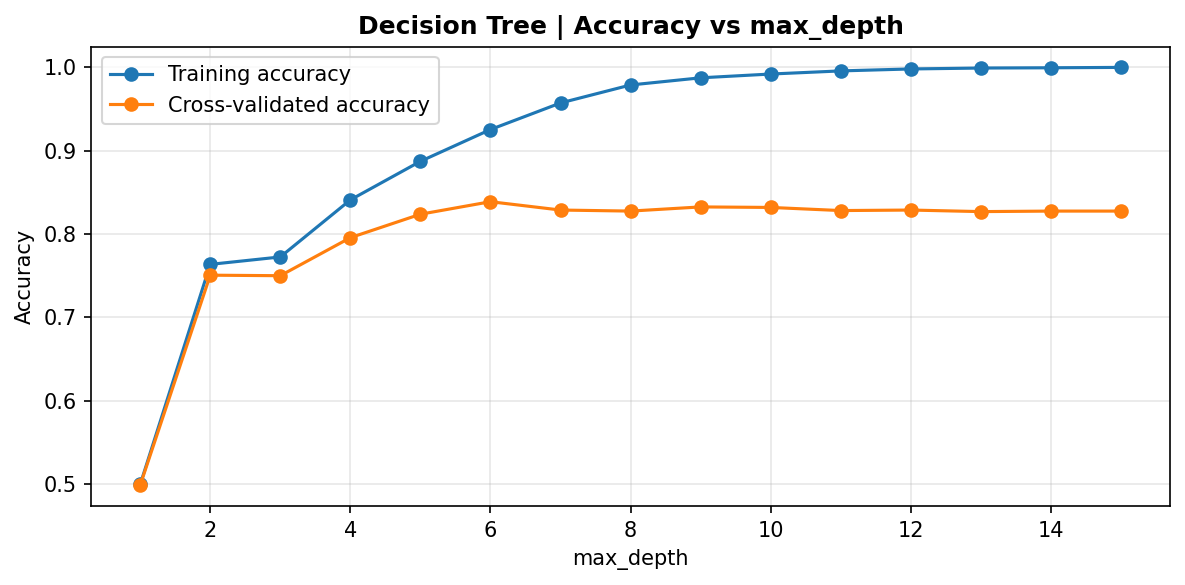

In [43]:
depths = range(1, 16)
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42), X_train_sel, y_train,
    param_name='max_depth', param_range=depths, cv=cv, scoring='accuracy', n_jobs=-1)

plt.figure(figsize=(8, 4), dpi=150)
plt.plot(depths, train_scores.mean(axis=1), marker='o', label='Training accuracy')
plt.plot(depths, val_scores.mean(axis=1), marker='o', label='Cross-validated accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree | Accuracy vs max_depth', weight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
dt_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid={'max_depth': range(2, 13), 'min_samples_leaf': [1, 5, 10]},
    scoring='accuracy', cv=cv, n_jobs=-1)
dt_search.fit(X_train_sel, y_train)

best_dt = dt_search.best_estimator_
print("Best parameters:", dt_search.best_params_)
print("Best cross-validated accuracy: {:.3f}".format(dt_search.best_score_))

Best parameters: {'max_depth': 6, 'min_samples_leaf': 5}
Best cross-validated accuracy: 0.844


#### Decision Tree Visualization

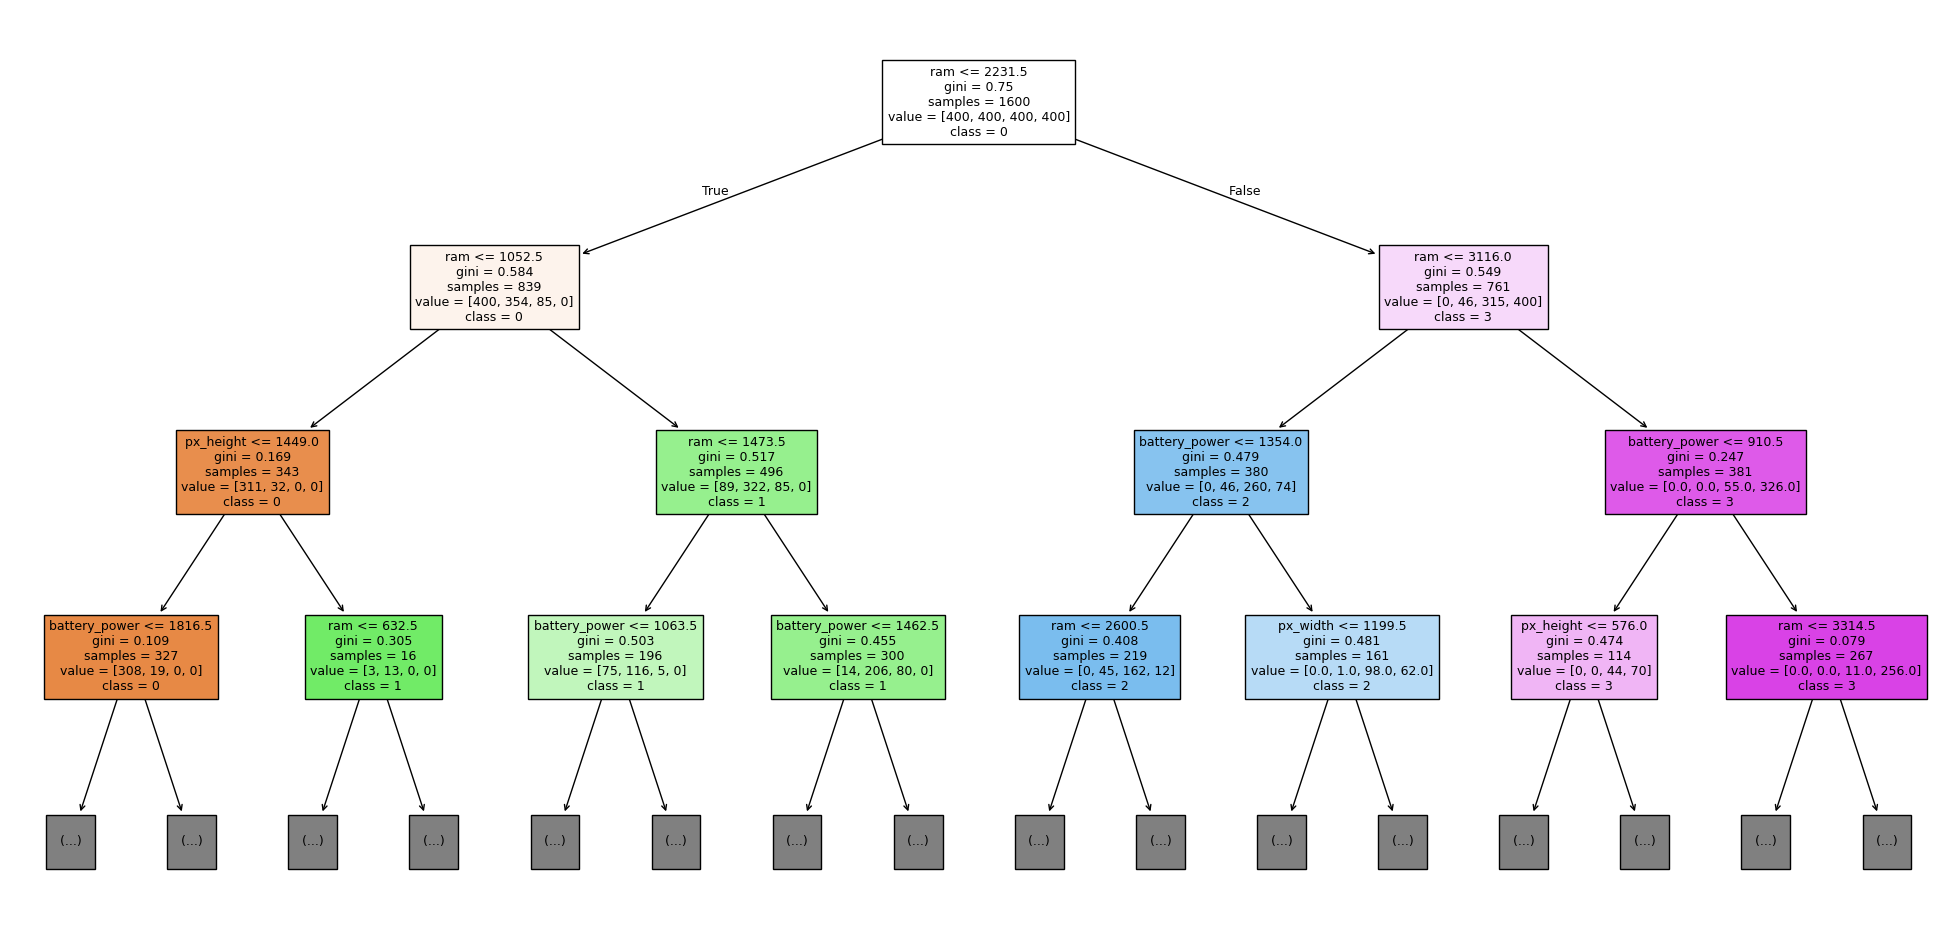

In [45]:
# Only the first 3 levels are drawn, for readability
plt.figure(figsize=(25, 12), dpi=100)
plot_tree(best_dt, feature_names=selected_features, class_names=['0', '1', '2', '3'],
          filled=True, max_depth=3, fontsize=9)
plt.show()

### Model 2 | Random Forest

A Random Forest averages many decision trees trained on random subsets of the data and features, which usually makes it more stable than a single tree. Its hyperparameters are tuned with `GridSearchCV` on the training set.

In [46]:
rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid={'n_estimators': [100, 200, 300],
                'max_depth': [6, 8, 10, 12, None],
                'criterion': ['gini', 'entropy']},
    scoring='accuracy', cv=cv, n_jobs=-1)
rf_search.fit(X_train_sel, y_train)

best_rf = rf_search.best_estimator_
print("Best parameters:", rf_search.best_params_)
print("Best cross-validated accuracy: {:.3f}".format(rf_search.best_score_))

Best parameters: {'criterion': 'entropy', 'max_depth': 12, 'n_estimators': 100}
Best cross-validated accuracy: 0.884


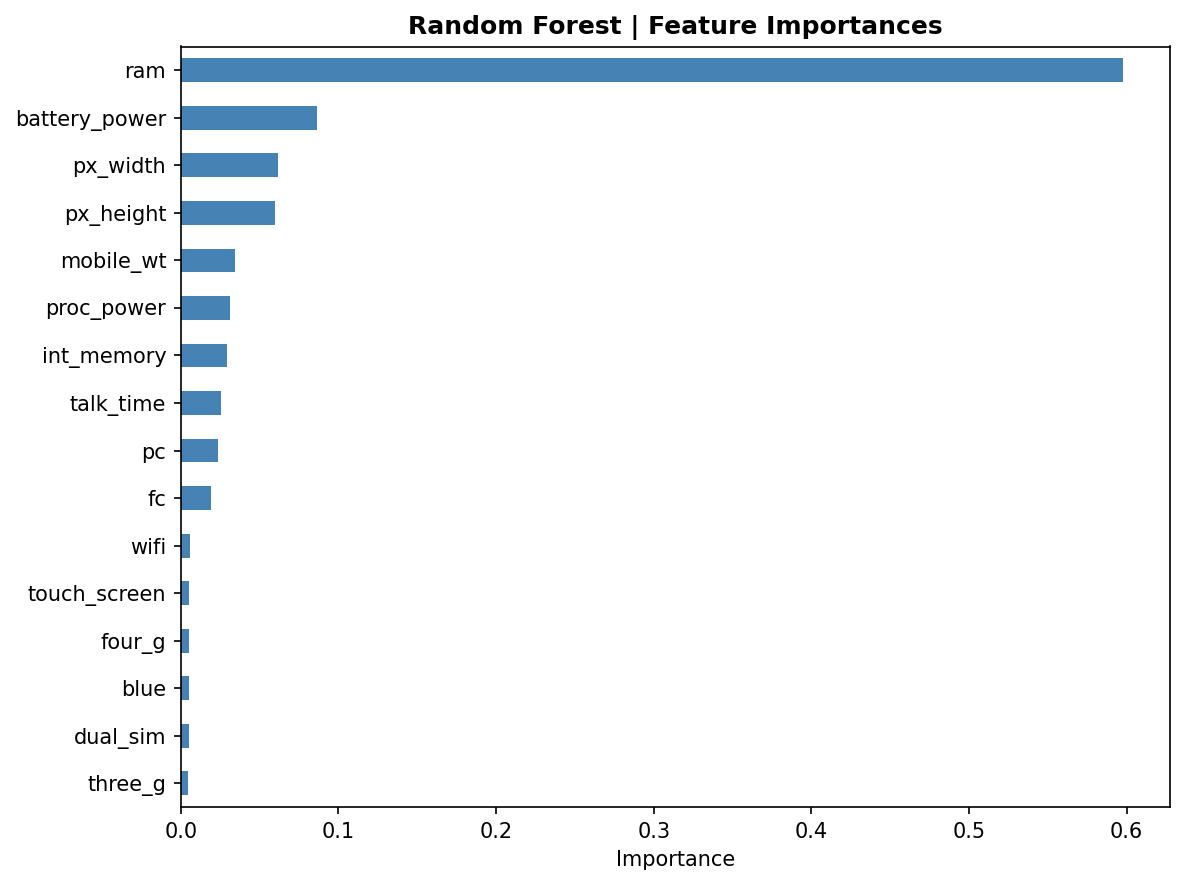

In [47]:
# Random Forest feature importances
importances = pd.Series(best_rf.feature_importances_, index=selected_features).sort_values()

plt.figure(figsize=(8, 6), dpi=150)
importances.plot(kind='barh', color='steelblue')
plt.title('Random Forest | Feature Importances', weight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### Model 3 | SVM (Support Vector Machine)

An SVM finds the boundary that separates the classes with the widest margin. It is sensitive to feature scale, so the min-max scaler is part of the pipeline.  The grid covers several kernels and a wide range of C. The best model is a linear SVM with C=1000, the upper end of the linear grid, so a larger C could help slightly; I kept the grid as is because the cross-validated accuracy is already 0.966.

In [48]:
svm_pipeline = Pipeline([('scaler', MinMaxScaler()), ('svm', SVC(random_state=42))])

svm_grid = [
    {'svm__kernel': ['linear'], 'svm__C': [0.1, 1, 10, 100, 1000]},
    {'svm__kernel': ['rbf', 'sigmoid'], 'svm__C': [0.1, 1, 10, 100, 1000],
     'svm__gamma': ['scale', 0.01, 0.1, 1]},
    {'svm__kernel': ['poly'], 'svm__C': [0.1, 1, 10, 100], 'svm__gamma': ['scale', 0.1, 1]},
]

svm_search = GridSearchCV(svm_pipeline, svm_grid, scoring='accuracy', cv=cv, n_jobs=-1)
svm_search.fit(X_train_sel, y_train)

best_svm = svm_search.best_estimator_
print("Best parameters:", svm_search.best_params_)
print("Best cross-validated accuracy: {:.3f}".format(svm_search.best_score_))

Best parameters: {'svm__C': 1000, 'svm__kernel': 'linear'}
Best cross-validated accuracy: 0.966


## Evaluation on the Test Set

All three tuned models are evaluated once on the same held-out test set. The cross-validated accuracy (from tuning) is shown next to the test scores.

In [49]:
tuned_models = {
    'Decision Tree': (best_dt, dt_search.best_score_),
    'Random Forest': (best_rf, rf_search.best_score_),
    'SVM': (best_svm, svm_search.best_score_),
}

rows = []
for name, (model, cv_score) in tuned_models.items():
    pred = model.predict(X_test_sel)
    rows.append({'Model': name,
                 'CV Accuracy': cv_score,
                 'Test Accuracy': accuracy_score(y_test, pred),
                 'Test Macro-F1': f1_score(y_test, pred, average='macro')})

results = pd.DataFrame(rows).set_index('Model')

# The final model is the one with the best cross-validated accuracy (not the best test score)
final_name = results['CV Accuracy'].idxmax()
print("Model with the best cross-validated accuracy:", final_name)
results.round(3)

Model with the best cross-validated accuracy: SVM


,CV Accuracy,Test Accuracy,Test Macro-F1
Model,,,
Decision Tree,0.844,0.852,0.853
Random Forest,0.884,0.905,0.905
SVM,0.966,0.970,0.970


### Confusion Matrices (test set)

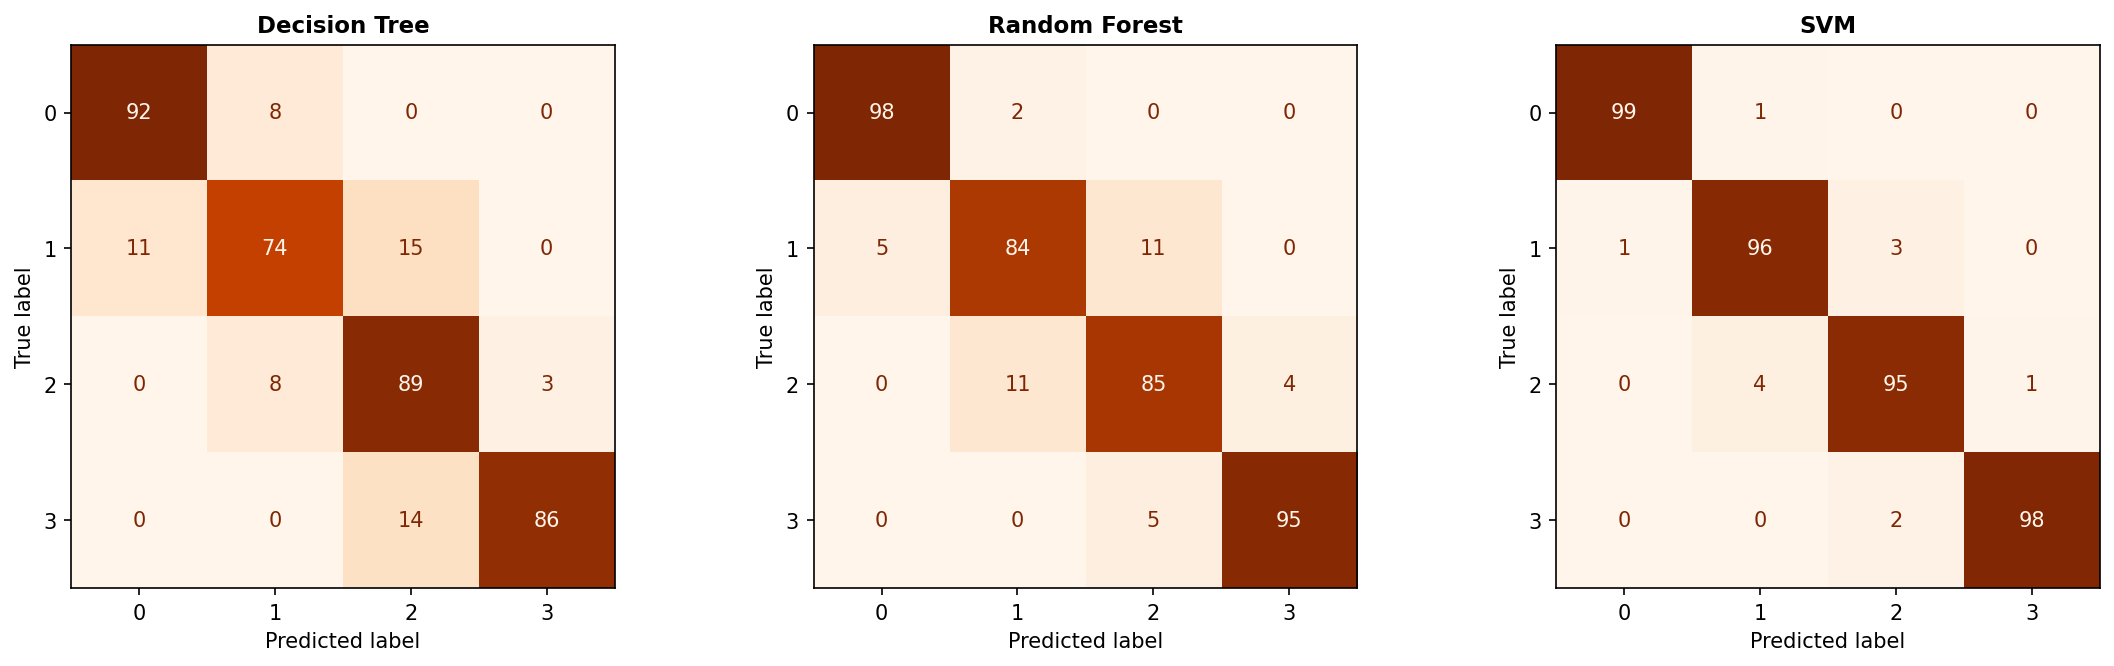

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=150)

for ax, (name, (model, _)) in zip(axes, tuned_models.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_test_sel, y_test, ax=ax,
                                          cmap='Oranges', colorbar=False)
    ax.set_title(name, fontsize=11, weight='bold')
    ax.grid(False)

plt.tight_layout()
plt.show()

In [51]:
print(f"Classification report | {final_name}")
print(classification_report(y_test, tuned_models[final_name][0].predict(X_test_sel)))

Classification report | SVM
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       100
           1       0.95      0.96      0.96       100
           2       0.95      0.95      0.95       100
           3       0.99      0.98      0.98       100

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



### How to Read the Results

- **Which model is best?** The final model is chosen by cross-validated accuracy on the training set. The test-set scores are then an honest estimate of how it performs on unseen phones. Choosing the model by looking at test scores would make those scores optimistic.
- **Ordered classes.** In the confusion matrices, mistakes between neighboring price ranges (e.g. 1 vs 2) are less costly than mistakes between distant ones (e.g. 0 vs 3). Look at where the off-diagonal counts sit.
- **Macro-F1** averages the F1 score of the four classes equally, so it shows whether the model works well for every price range and not just for the easy ones.
- **Decision Tree vs Random Forest vs SVM.** A single tree is easy to explain but tends to overfit. The Random Forest is more stable, and the SVM works well when the classes can be separated by a smooth boundary in the scaled feature space. The table above shows which of these wins on this dataset.

## Prediction on the Unlabeled Test File

The second file (`test.csv`) has no price range, so its predictions cannot be scored here. To predict it, the final model is refitted on **all** labelled data, and the new phones get the same engineered feature (`proc_power`) as the training data. Because the model is a pipeline, the scaling learned from the training data is applied automatically (the scaler is never refitted on the new phones).

In [52]:
#data_test

Data_test = pd.read_csv("../data/test.csv")
df_test = Data_test.copy()

# Same feature engineering as for the training data
df_test["proc_power"] = df_test["clock_speed"] * df_test["n_cores"]

# Refit the final model on all labelled data, then predict
final_model = clone(tuned_models[final_name][0])
final_model.fit(X[selected_features], y)

predictions = pd.DataFrame({
    'id': df_test['id'],
    'predicted_price_range': final_model.predict(df_test[selected_features])})

print("Predicted phones:", len(predictions))
predictions.head(10)

Predicted phones: 1000


,id,predicted_price_range
0,1,3
1,2,3
2,3,2
3,4,3
4,5,1
5,6,3
6,7,3
7,8,1
8,9,3
9,10,0


predicted_price_range
0    250
1    232
2    256
3    262
Name: count, dtype: int64


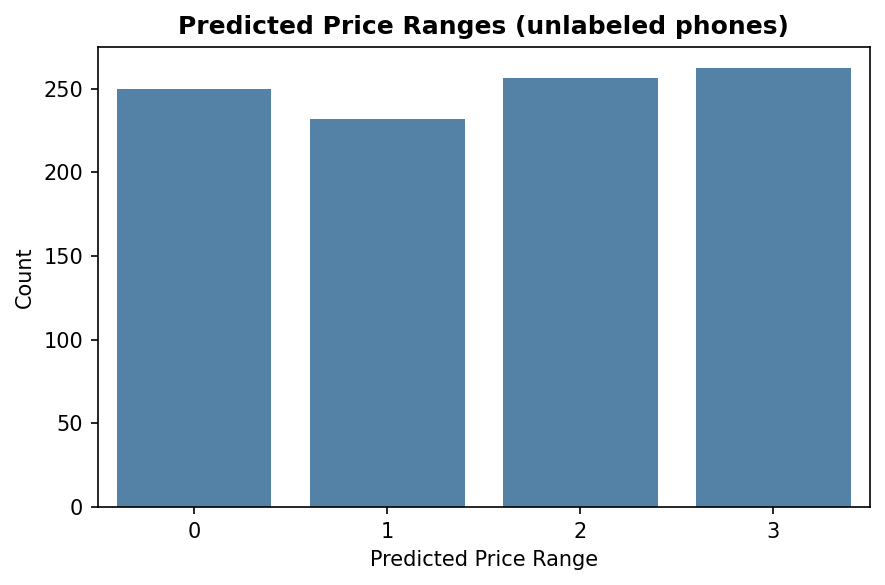

In [53]:
# Sanity check: distribution of the predicted price ranges
print(predictions['predicted_price_range'].value_counts().sort_index())

plt.figure(figsize=(6, 4), dpi=150)
sns.countplot(data=predictions, x='predicted_price_range', color='steelblue')
plt.title('Predicted Price Ranges (unlabeled phones)', fontsize=12, weight='bold')
plt.xlabel('Predicted Price Range')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The predicted classes should look reasonably balanced if the unlabeled phones come from the same source as the training phones. A very lopsided distribution would be a warning sign.

## Conclusion & Next Steps

**What the analysis shows**

- RAM has the strongest observed relationship with price range and is the most informative feature for prediction in this dataset. Weight, talk time and most on/off features show almost no relationship with price in this dataset.
- Some columns contain implausible values (for example screens that are 0 cm wide), which suggests the data is noisy or partly synthetic.
- Which columns to keep and which hyperparameters to use were decided with cross-validation on the training set, and all models were compared on the same untouched test set.
- The best model is a linear SVM with 97.0% test accuracy and macro-F1, compared with 90.5% for Random Forest and 85.2% for Decision Tree. The classes are close to linearly separable.

**Limitations**

- One train/test split; repeated cross-validation would give a more stable estimate.
- The price range is a label (0-3) and not a real price, so the model cannot say how much a phone costs.

**Next steps**

- Build an interactive dashboard (for example in Tableau) with the main findings: price range by RAM, battery power and resolution.
- Try Logistic Regression and Gradient Boosting, and explain the final model with permutation importance.